# Seismic signals preprocessing and exploration

This notebook covers the loading, preprocessing, and exploratory analysis of the seismic acceleration signals. A single preprocessing pipeline is applied to all 66 signals (baseline correction and normalization). A filtered version  excluding the 6 short-signal stations (SURF, BRZ, BHB, CRI, SLZ, SAV) is also saved for use in the moment scaling analysis, which requires signals of sufficient length to produce reliable displacement increment estimates.

## 1. Imports and visualization settings

In [22]:
from pathlib import Path
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib as mpl
from src.io import build_accelerations
from src.io import build_metadata
from src.cleaning_signals import preprocess_signals_single, preprocess_signals_long
from src.cleaning_metadata import clean_metadata
from src.plot_settings import set_plot_style
from IPython.display import display
from src.latex_export import preprocess_checks_to_latex
colors = set_plot_style()

## 2. Data loading

Raw acceleration data are loaded from the zip archive containing the `.ASC` files.
The function `build_accelerations` extracts the acceleration time series from 
each file and returns a dataframe with columns `file`, `sample`, and `acceleration`.

In [23]:
# Load and preprocess data
zip_path = Path("..") / "data" / "raw" / "query.zip"
df_acc = build_accelerations(zip_path)
df_meta = build_metadata(zip_path)
df_meta_clean = clean_metadata(df_meta)

In [24]:
# Figures output directory
FIGURES_DIR = Path('../figures/02_signals')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## 3. Signals exploration

A first exploration of the raw acceleration signals is performed to understand 
the structure of the dataset before preprocessing. Signal lengths, amplitude 
distributions, and example waveforms are inspected.

### Signal length distribution

The number of samples varies across signals. Understanding the distribution 
of signal lengths is important for deciding how to handle signals of different 
lengths in the aggregated analysis.

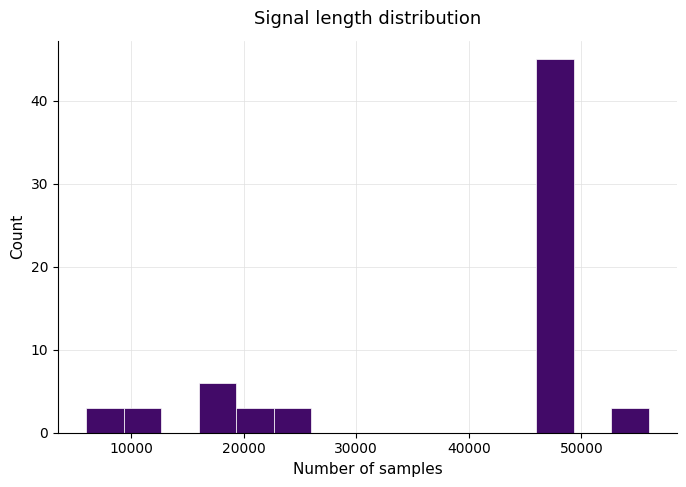

In [25]:
# Signal length distribution
signal_lengths = df_acc.groupby('file')['sample'].max() + 1

fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(signal_lengths, bins=15, color=colors[0], edgecolor='white', linewidth=0.5)
ax.set_title('Signal length distribution')
ax.set_xlabel('Number of samples')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'signal_length_distribution.pdf', bbox_inches='tight')
plt.show()

### Example signals

Example acceleration time series are plotted for each component (HNE, HNN, HNZ) 
to visualize the typical structure of the signals: pre-event noise, 
seismic wave arrival, and coda.

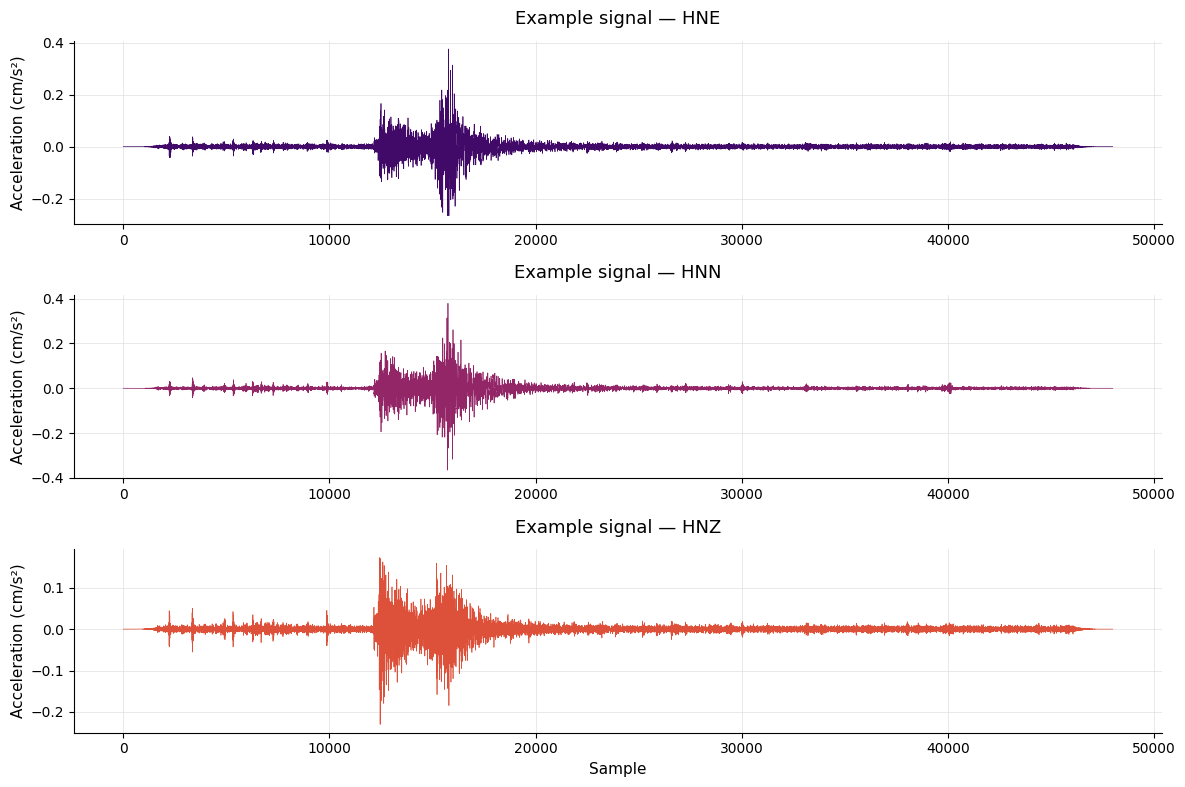

In [26]:
# Display example signals for each stream
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=False)

for i, stream in enumerate(['HNE', 'HNN', 'HNZ']):
    example_file = df_meta_clean[df_meta_clean['STREAM'] == stream]['file'].iloc[0]
    signal = df_acc[df_acc['file'] == example_file]
    axes[i].plot(signal['sample'], signal['acceleration'],
                 color=colors[i], linewidth=0.5)
    axes[i].set_title(f'Example signal — {stream}')
    axes[i].set_ylabel('Acceleration (cm/s²)')

axes[2].set_xlabel('Sample')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'example_signals.pdf', bbox_inches='tight')
plt.show()

### Acceleration distribution

The distribution of acceleration values is visualized on a logarithmic scale 
to better appreciate the heavy tails of the distribution. The dominance of 
near-zero values reflects the long pre-event and post-event noise windows.

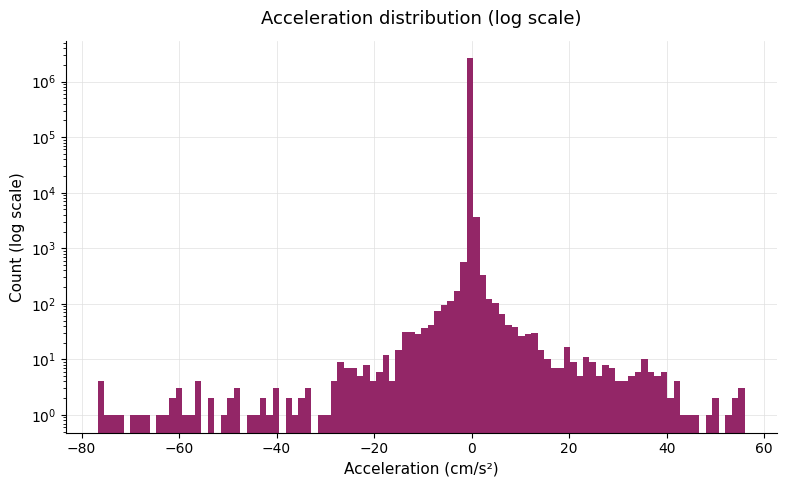

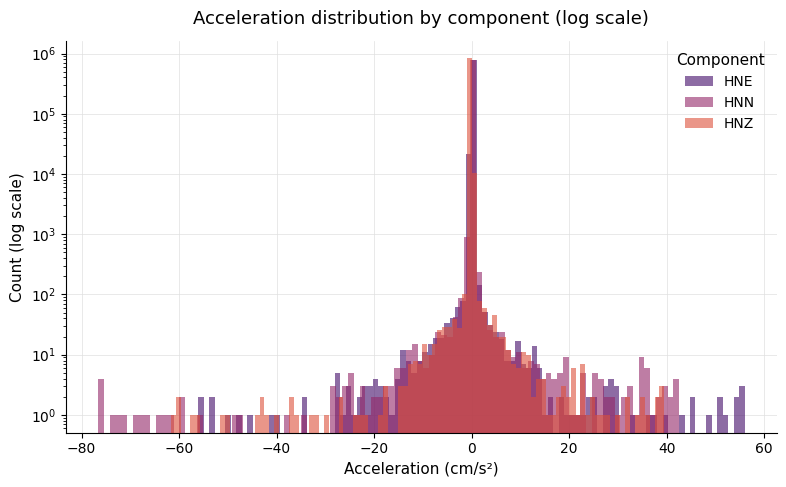

In [27]:
# Global acceleration distribution (log scale)
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df_acc['acceleration'], bins=100, color=colors[1], edgecolor='none')
ax.set_yscale('log')
ax.set_title('Acceleration distribution (log scale)')
ax.set_xlabel('Acceleration (cm/s²)')
ax.set_ylabel('Count (log scale)')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'acceleration_distribution.pdf', bbox_inches='tight')
plt.show()

# Acceleration distribution by component (log scale)
fig, ax = plt.subplots(figsize=(8, 5))
for i, stream in enumerate(['HNE', 'HNN', 'HNZ']):
    files = df_meta_clean[df_meta_clean['STREAM'] == stream]['file'].values
    acc_values = df_acc[df_acc['file'].isin(files)]['acceleration'].values
    ax.hist(acc_values, bins=100, color=colors[i], alpha=0.6,
            label=stream, edgecolor='none')
ax.set_yscale('log')
ax.set_title('Acceleration distribution by component (log scale)')
ax.set_xlabel('Acceleration (cm/s²)')
ax.set_ylabel('Count (log scale)')
ax.legend(title='Component')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'acceleration_by_component.pdf', bbox_inches='tight')
plt.show()

### Extreme acceleration values check

Signals with acceleration values below $-40$ cm/s² are identified to verify 
that extreme values are physically plausible and not due to data errors.

In [28]:
# Examine extreme values
print(df_acc[df_acc['acceleration'] < -40]['file'].unique())

['FR.SURF.00.HNE.D.INT-41004391.ACC.MP.ASC'
 'FR.SURF.00.HNN.D.INT-41004391.ACC.MP.ASC'
 'FR.SURF.00.HNZ.D.INT-41004391.ACC.MP.ASC']


## 4. Preprocessing

The preprocessing pipeline consists of two steps applied to all 66 signals:

1. **Baseline correction** — the mean of each signal is subtracted to ensure 
   zero baseline:
   $$a'(t) = a(t) - \bar{a}$$

2. **Normalization** — each signal is divided by its standard deviation to 
   allow comparison across stations with different amplitudes:
   $$\hat{a}(t) = \frac{a'(t)}{\sigma_a}$$

After normalization, each signal has zero mean and unit standard deviation. The resulting dataframe `df_acc_clean` contains all 66 signals and is used for PDF analysis and heavy-tail assessment in notebooks 3 and 4.


### Preprocessing

In [29]:
# Preprocess single signals
df_acc_clean = preprocess_signals_single(df_acc)
print(df_acc_clean.shape)
display(df_acc_clean.head())
display(df_acc_clean[['acceleration', 'acceleration_normalized']].describe())

(2614815, 4)


,file,sample,acceleration,acceleration_normalized
0,FR.EILF.00.HNE.D.INT-41004391.ACC.MP.ASC,0,-6.666667e-10,-3.401661e-08
1,FR.EILF.00.HNE.D.INT-41004391.ACC.MP.ASC,1,-6.666667e-10,-3.401661e-08
2,FR.EILF.00.HNE.D.INT-41004391.ACC.MP.ASC,2,-6.666667e-10,-3.401661e-08
3,FR.EILF.00.HNE.D.INT-41004391.ACC.MP.ASC,3,-6.666667e-10,-3.401661e-08
4,FR.EILF.00.HNE.D.INT-41004391.ACC.MP.ASC,4,-6.666667e-10,-3.401661e-08


,acceleration,acceleration_normalized
count,2.614815e+06,2.614815e+06
mean,4.731320e-20,6.854573e-19
std,3.865810e-01,9.999876e-01
min,-7.663142e+01,-3.300176e+01
25%,-9.249986e-04,-5.137990e-02
50%,-5.000000e-10,-2.139984e-08
75%,9.219988e-04,5.086609e-02
max,5.600939e+01,3.318042e+01


### Post-preprocessing check and saving

The preprocessed dataframe is inspected to verify that baseline correction 
and normalization have been applied correctly. The preprocessed data are 
saved to a parquet file for use in notebook 03.

In [30]:
# 1. Baseline check — mean per file should be ~0
baseline_check = df_acc_clean.groupby('file')['acceleration'].mean()
print("Max residual mean:", baseline_check.abs().max())
print("Any mean > 1e-10?", (baseline_check.abs() > 1e-10).any())

# 2. Normalization check — std per file should be ~1
norm_check = df_acc_clean.groupby('file')['acceleration_normalized'].std()
print("\nMean std:", norm_check.mean())
print("Any std far from 1?", ((norm_check - 1).abs() > 1e-6).any())

# 3. No NaN or inf
print("\nNaN in acceleration:", df_acc_clean['acceleration'].isna().sum())
print("NaN in acceleration_normalized:", df_acc_clean['acceleration_normalized'].isna().sum())
print("Inf in acceleration:", np.isinf(df_acc_clean['acceleration']).sum())
print("Inf in acceleration_normalized:", np.isinf(df_acc_clean['acceleration_normalized']).sum())

# 4. Shape unchanged
print("\nShape:", df_acc_clean.shape)
print("N files:", df_acc_clean['file'].nunique())

Max residual mean: 1.9072905147604626e-17
Any mean > 1e-10? False

Mean std: 1.0
Any std far from 1? False

NaN in acceleration: 0
NaN in acceleration_normalized: 0
Inf in acceleration: 0
Inf in acceleration_normalized: 0

Shape: (2614815, 4)
N files: 66


In [31]:
# Save preprocessed data to parquet for later use
try:
    df_acc_clean.to_parquet('../data/processed/acc_preprocessed_all.parquet', index=False)
    print("Saved successfully!")
except Exception as e:
    print(f"Error saving file: {e}")

Saved successfully!


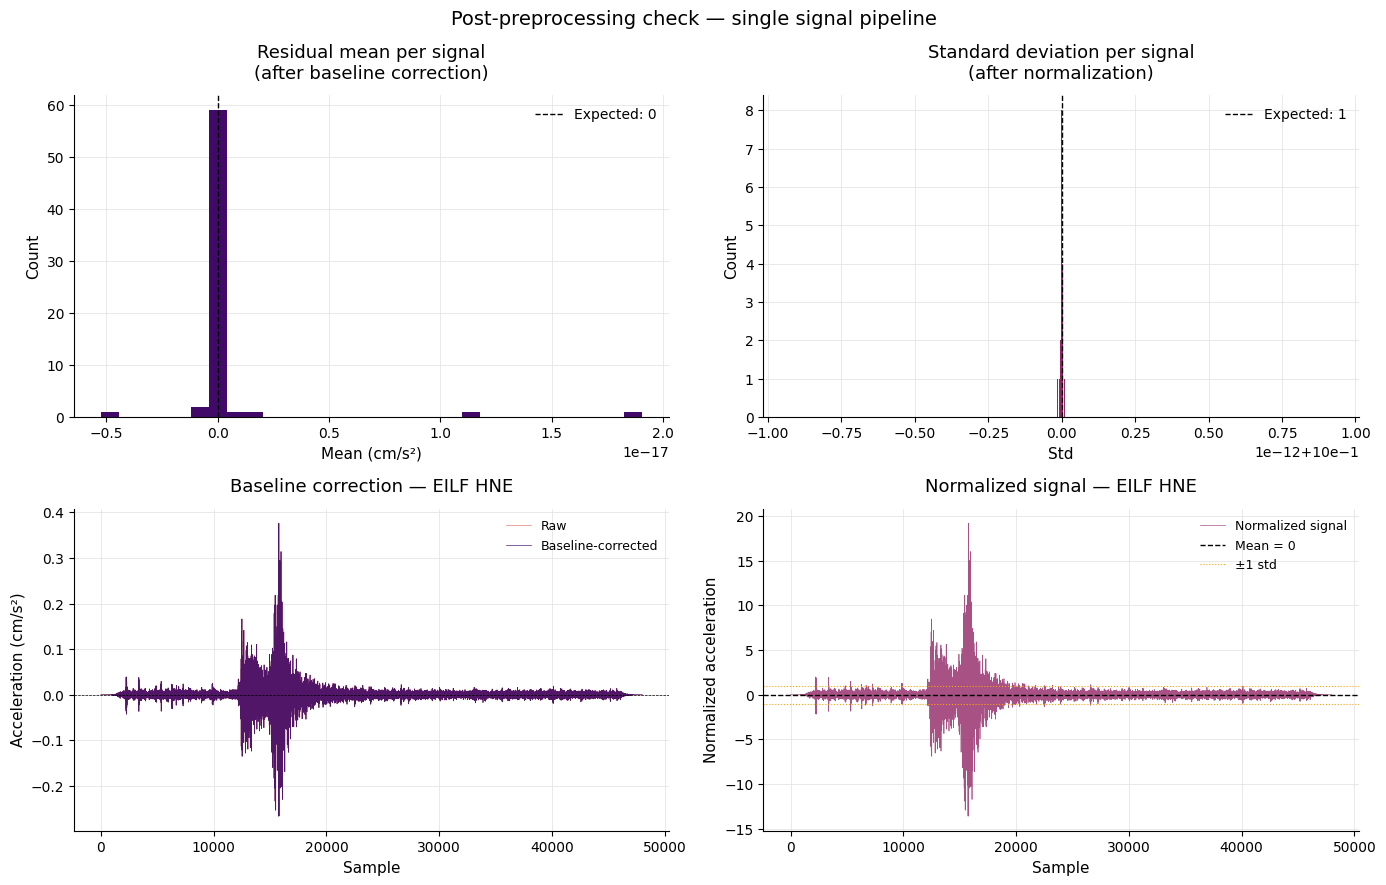

Saved: postcheck_single.pdf


In [32]:
# Dati per i check
baseline_check = df_acc_clean.groupby('file')['acceleration'].mean()
norm_check     = df_acc_clean.groupby('file')['acceleration_normalized'].std()

# Scegli un file di esempio (la prima stazione disponibile)
example_file   = df_acc_clean['file'].unique()[0]
example_raw    = df_acc[df_acc['file'] == example_file]['acceleration'].values
example_bc     = df_acc_clean[df_acc_clean['file'] == example_file]['acceleration'].values
example_norm   = df_acc_clean[df_acc_clean['file'] == example_file]['acceleration_normalized'].values
station_label  = example_file.split('.')[1] + ' ' + example_file.split('.')[3]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# 1. Distribuzione delle medie per file
axes[0, 0].hist(baseline_check.values, bins=30, color=colors[0], edgecolor='none')
axes[0, 0].axvline(0, color='black', linewidth=1, linestyle='--', label='Expected: 0')
axes[0, 0].set_title('Residual mean per signal\n(after baseline correction)')
axes[0, 0].set_xlabel('Mean (cm/s²)')
axes[0, 0].set_ylabel('Count')
axes[0, 0].legend()

# 2. Distribuzione delle std per file
axes[0, 1].hist(norm_check.values, bins=30, color=colors[1], edgecolor='none')
axes[0, 1].axvline(1, color='black', linewidth=1, linestyle='--', label='Expected: 1')
axes[0, 1].set_title('Standard deviation per signal\n(after normalization)')
axes[0, 1].set_xlabel('Std')
axes[0, 1].set_ylabel('Count')
axes[0, 1].legend()

# 3. Segnale grezzo vs baseline-corrected
t = np.arange(len(example_raw))
axes[1, 0].plot(t, example_raw,  color=colors[2], linewidth=0.5,
                alpha=0.7, label='Raw')
axes[1, 0].plot(t, example_bc,   color=colors[0], linewidth=0.5,
                alpha=0.9, label='Baseline-corrected')
axes[1, 0].axhline(0, color='black', linewidth=0.5, linestyle='--')
axes[1, 0].set_title(f'Baseline correction — {station_label}')
axes[1, 0].set_xlabel('Sample')
axes[1, 0].set_ylabel('Acceleration (cm/s²)')
axes[1, 0].legend(fontsize=9)

# 4. Segnale normalizzato con mean e ±1 std evidenziati
axes[1, 1].plot(t, example_norm, color=colors[1], linewidth=0.5, alpha=0.8,
                label='Normalized signal')
axes[1, 1].axhline(0,  color='black',    linewidth=1,   linestyle='--', label='Mean = 0')
axes[1, 1].axhline( 1, color=colors[3],  linewidth=0.8, linestyle=':',  label='±1 std')
axes[1, 1].axhline(-1, color=colors[3],  linewidth=0.8, linestyle=':')
axes[1, 1].set_title(f'Normalized signal — {station_label}')
axes[1, 1].set_xlabel('Sample')
axes[1, 1].set_ylabel('Normalized acceleration')
axes[1, 1].legend(fontsize=9)

plt.suptitle('Post-preprocessing check — single signal pipeline', fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'postcheck_single.pdf', bbox_inches='tight')
plt.show()
print("Saved: postcheck_single.pdf")

## 5. Filtered preprocessing for moment scaling analysis

The moment scaling analysis (notebooks 3 and 4) requires signals of sufficient length to produce reliable displacement increment estimates at large time scales $\tau$. Signals with fewer than 48,000 samples (stations SURF, BRZ, BHB, CRI, SLZ, SAV) are excluded. The remaining 48 signals are saved separately. The preprocessing pipeline consists of three steps:

1. **Truncation** — only signals with at least $48000$ samples are retained, 
   and all signals are truncated to exactly $48000$ samples. This excludes 
   6 stations (SURF, BRZ, BHB, CRI, SLZ, SAV) whose signals are shorter 
   due to their proximity to the epicenter.

2. **Baseline correction** — same as in the single signal pipeline.

3. **Normalization** — same as in the single signal pipeline.

In [33]:
# Display signal length distribution
signal_lengths = df_acc.groupby('file')['sample'].max() + 1
pd.set_option('display.max_rows', None)
print(signal_lengths.sort_values())
pd.reset_option('display.max_rows')

file
FR.SURF.00.HNE.D.INT-41004391.ACC.MP.ASC     6000
FR.SURF.00.HNZ.D.INT-41004391.ACC.MP.ASC     6000
FR.SURF.00.HNN.D.INT-41004391.ACC.MP.ASC     6000
IT.BRZ..HGE.D.INT-41004391.ACC.MP.ASC       11001
IT.BRZ..HGZ.D.INT-41004391.ACC.MP.ASC       11001
IT.BRZ..HGN.D.INT-41004391.ACC.MP.ASC       11001
GU.BHB..HNE.D.INT-41004391.ACC.MP.ASC       16601
GU.BHB..HNN.D.INT-41004391.ACC.MP.ASC       16601
GU.BHB..HNZ.D.INT-41004391.ACC.MP.ASC       16601
IT.CRI..HNZ.D.INT-41004391.ACC.MP.ASC       19001
IT.CRI..HNE.D.INT-41004391.ACC.MP.ASC       19001
IT.CRI..HNN.D.INT-41004391.ACC.MP.ASC       19001
IT.SLZ..HNZ.D.INT-41004391.ACC.MP.ASC       20001
IT.SLZ..HNN.D.INT-41004391.ACC.MP.ASC       20001
IT.SLZ..HNE.D.INT-41004391.ACC.MP.ASC       20001
IT.SAV..HGE.D.INT-41004391.ACC.MP.ASC       23001
IT.SAV..HGN.D.INT-41004391.ACC.MP.ASC       23001
IT.SAV..HGZ.D.INT-41004391.ACC.MP.ASC       23001
FR.SAOF.00.HNN.D.INT-41004391.ACC.MP.ASC    48000
FR.REVF.00.HN2.D.INT-41004391.ACC.MP.ASC    4

### Preprocessing

In [34]:
# Preprocess — long signals only (used for moment scaling analysis)
df_acc_long = preprocess_signals_long(df_acc)
print(df_acc_long.shape)
display(df_acc_long.describe())

(2328000, 4)


,sample,acceleration,acceleration_normalized
count,2.328000e+06,2.328000e+06,2.328000e+06
mean,2.428816e+04,1.307190e-20,7.405540e-19
std,1.407391e+04,1.992689e-02,9.999899e-01
min,0.000000e+00,-9.768020e-01,-3.300176e+01
25%,1.212475e+04,-8.209985e-04,-5.016902e-02
50%,2.424950e+04,-5.000000e-10,-2.139984e-08
75%,3.637425e+04,8.189995e-04,4.972788e-02
max,5.599900e+04,7.343670e-01,3.318042e+01


### Post-preprocessing check and saving

The preprocessed dataframe is inspected to verify that filtering, baseline correction, and normalization have been applied correctly. The preprocessed data are saved to a parquet file for use in notebooks 3 and 4.

In [35]:
# 1. Filter check — only files with >= 48000 samples should be retained
signal_lengths_long = df_acc_long.groupby('file')['sample'].max() + 1
print("N files after filtering:", df_acc_long['file'].nunique())
print("Signal lengths:\n", signal_lengths_long.value_counts())

# 2. Baseline check — mean per file should be ~0
baseline_check = df_acc_long.groupby('file')['acceleration'].mean()
print("\nMax residual mean:", baseline_check.abs().max())
print("Any mean > 1e-10?", (baseline_check.abs() > 1e-10).any())

# 3. Normalization check — std per file should be ~1
norm_check = df_acc_long.groupby('file')['acceleration_normalized'].std()
print("\nMean std:", norm_check.mean())
print("Any std far from 1?", ((norm_check - 1).abs() > 1e-6).any())

# 4. No NaN or inf
print("\nNaN in acceleration:", df_acc_long['acceleration'].isna().sum())
print("NaN in acceleration_normalized:", df_acc_long['acceleration_normalized'].isna().sum())
print("Inf in acceleration:", np.isinf(df_acc_long['acceleration']).sum())
print("Inf in acceleration_normalized:", np.isinf(df_acc_long['acceleration_normalized']).sum())

# 5. Shape
print("\nShape:", df_acc_long.shape)

N files after filtering: 48
Signal lengths:
 sample
48000    45
56000     3
Name: count, dtype: int64

Max residual mean: 1.2916139839021171e-19
Any mean > 1e-10? False

Mean std: 1.0000000000000002
Any std far from 1? False

NaN in acceleration: 0
NaN in acceleration_normalized: 0
Inf in acceleration: 0
Inf in acceleration_normalized: 0

Shape: (2328000, 4)


In [36]:
# Save preprocessed data — long signals only (used for moment scaling analysis)
try:
    df_acc_long.to_parquet('../data/processed/acc_preprocessed_long.parquet', index=False)
    print("Saved successfully!")
except Exception as e:
    print(f"Error saving file: {e}")

Saved successfully!


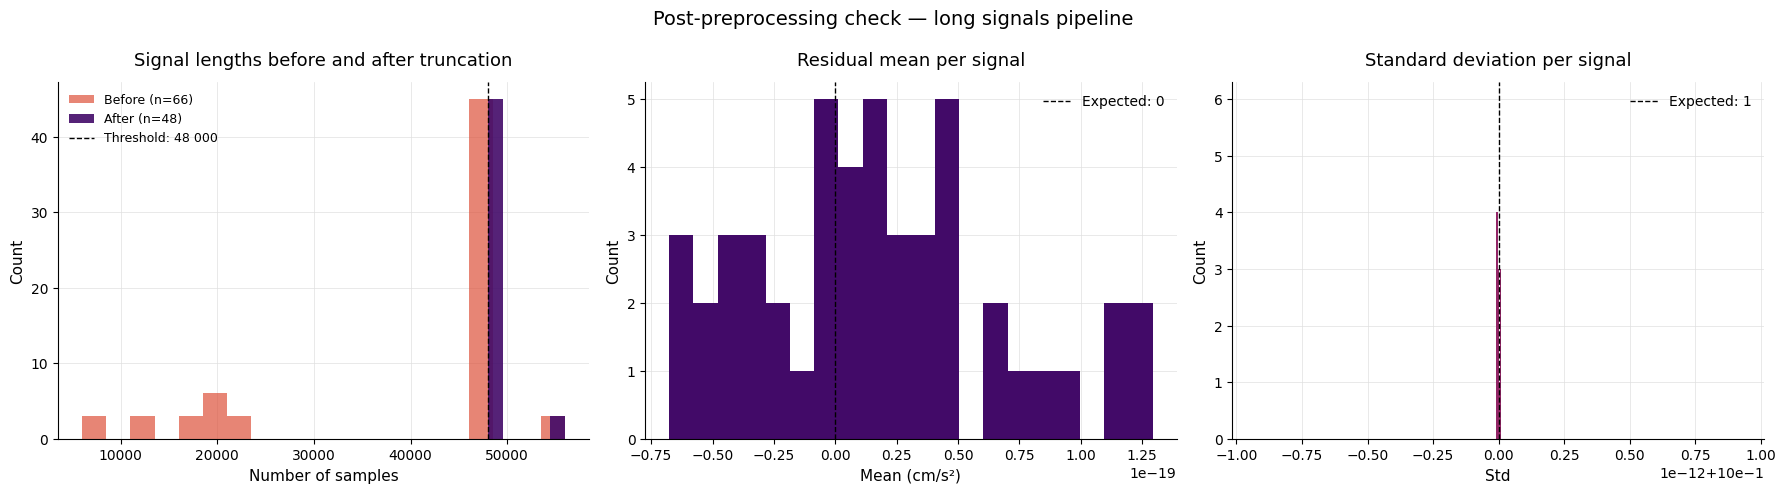

Saved: postcheck_long.pdf


In [37]:
baseline_check_agg = df_acc_long.groupby('file')['acceleration'].mean()
norm_check_agg     = df_acc_long.groupby('file')['acceleration_normalized'].std()
signal_lengths_raw = df_acc.groupby('file')['sample'].max() + 1
signal_lengths_long = df_acc_long.groupby('file')['sample'].max() + 1

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Signal length distribution before and after truncation
axes[0].hist(signal_lengths_raw.values, bins=20, color=colors[2],
             edgecolor='none', alpha=0.7, label=f'Before (n={len(signal_lengths_raw)})')
axes[0].hist(signal_lengths_long.values, bins=5, color=colors[0],
             edgecolor='none', alpha=0.9, label=f'After (n={len(signal_lengths_long)})')
axes[0].axvline(48000, color='black', linewidth=1, linestyle='--',
                label='Threshold: 48 000')
axes[0].set_title('Signal lengths before and after truncation')
axes[0].set_xlabel('Number of samples')
axes[0].set_ylabel('Count')
axes[0].legend(fontsize=9)

# Residual mean distribution
axes[1].hist(baseline_check_agg.values, bins=20, color=colors[0], edgecolor='none')
axes[1].axvline(0, color='black', linewidth=1, linestyle='--', label='Expected: 0')
axes[1].set_title('Residual mean per signal')
axes[1].set_xlabel('Mean (cm/s²)')
axes[1].set_ylabel('Count')
axes[1].legend()

# Std distribution
axes[2].hist(norm_check_agg.values, bins=20, color=colors[1], edgecolor='none')
axes[2].axvline(1, color='black', linewidth=1, linestyle='--', label='Expected: 1')
axes[2].set_title('Standard deviation per signal')
axes[2].set_xlabel('Std')
axes[2].set_ylabel('Count')
axes[2].legend()

plt.suptitle('Post-preprocessing check — long signals pipeline', fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'postcheck_long.pdf', bbox_inches='tight')
plt.show()
print("Saved: postcheck_long.pdf")

## Summary

In [38]:
# Single pipeline
bl_max_single   = baseline_check.abs().max()
bl_pass_single  = bl_max_single < 1e-10
std_mean_single = norm_check.mean()
std_pass_single = ((norm_check - 1).abs() > 1e-6).sum() == 0
nan_acc_single  = df_acc_clean['acceleration'].isna().sum()
nan_norm_single = df_acc_clean['acceleration_normalized'].isna().sum()
inf_acc_single  = np.isinf(df_acc_clean['acceleration']).sum()
inf_norm_single = np.isinf(df_acc_clean['acceleration_normalized']).sum()
n_files_single  = df_acc_clean['file'].nunique()

# Long signals only pipeline
bl_max_agg   = baseline_check_agg.abs().max()
bl_pass_agg  = bl_max_agg < 1e-10
std_mean_agg = norm_check_agg.mean()
std_pass_agg = ((norm_check_agg - 1).abs() > 1e-6).sum() == 0
nan_acc_agg  = df_acc_long['acceleration'].isna().sum()
nan_norm_agg = df_acc_long['acceleration_normalized'].isna().sum()
inf_acc_agg  = np.isinf(df_acc_long['acceleration']).sum()
inf_norm_agg = np.isinf(df_acc_long['acceleration_normalized']).sum()
n_files_agg  = df_acc_long['file'].nunique()
trunc_excluded = len(signal_lengths_raw) - n_files_agg

rows = [
    ('Files retained',
     f'{n_files_single} / {len(signal_lengths_raw)}',
     f'{n_files_agg} / {len(signal_lengths_raw)} ({trunc_excluded} excluded)',
     '—',           '—'),
    ('Max residual mean (cm/s²)',
     f'{bl_max_single:.2e}',
     f'{bl_max_agg:.2e}',
     '< 1e-10',     '\\checkmark' if (bl_pass_single and bl_pass_agg) else '\\times'),
    ('Mean std (normalized)',
     f'{std_mean_single:.8f}',
     f'{std_mean_agg:.8f}',
     '$\\approx 1$', '\\checkmark' if (std_pass_single and std_pass_agg) else '\\times'),
    ('NaN in acceleration',
     str(nan_acc_single),
     str(nan_acc_agg),
     '0',           '\\checkmark' if nan_acc_single == 0 and nan_acc_agg == 0 else '\\times'),
    ('NaN in acceleration\_normalized',
     str(nan_norm_single),
     str(nan_norm_agg),
     '0',           '\\checkmark' if nan_norm_single == 0 and nan_norm_agg == 0 else '\\times'),
    ('Inf in acceleration',
     str(inf_acc_single),
     str(inf_acc_agg),
     '0',           '\\checkmark' if inf_acc_single == 0 and inf_acc_agg == 0 else '\\times'),
    ('Inf in acceleration\_normalized',
     str(inf_norm_single),
     str(inf_norm_agg),
     '0',           '\\checkmark' if inf_norm_single == 0 and inf_norm_agg == 0 else '\\times'),
]

df_check = pd.DataFrame(rows, columns=['Check', 'Single pipeline',
                                        'Aggregated pipeline', 'Expected', 'Pass'])
display(df_check)

,Check,Single pipeline,Aggregated pipeline,Expected,Pass
0,Files retained,66 / 66,48 / 66 (18 excluded),—,—
1,Max residual mean (cm/s²),1.29e-19,1.29e-19,< 1e-10,\checkmark
2,Mean std (normalized),1.00000000,1.00000000,$\approx 1$,\checkmark
3,NaN in acceleration,0,0,0,\checkmark
4,NaN in acceleration\_normalized,0,0,0,\checkmark
5,Inf in acceleration,0,0,0,\checkmark
6,Inf in acceleration\_normalized,0,0,0,\checkmark


In [39]:
latex_table = preprocess_checks_to_latex(rows, output_path='../data/processed/preprocess_checks_table.tex')

Saved to: ../data/processed/preprocess_checks_table.tex
